# Student Performance Predictor

## Data Science Internship – Phase 1

### 1. Project Overview

This project uses machine learning to predict student examination
performance based on academic, behavioral, and personal factors.

### 2. Problem Statement

Educational institutions need to understand the factors that influence
student performance and identify students who may require additional
academic support. This project analyzes student-related data and builds
machine learning models to predict examination scores.

### 3. Objectives

- Analyze student performance data
- Perform data cleaning and preprocessing
- Explore relationships between academic factors and exam scores
- Analyze the effect of study hours and attendance on performance
- Perform exploratory data analysis using visualizations
- Build regression machine learning models
- Predict student examination scores
- Compare different regression models
- Evaluate model performance using MAE, MSE, and R² Score

### 4. Dataset

The project uses the Student Performance Factors dataset obtained
from Kaggle.

The dataset contains information about students' study habits,
attendance, previous academic performance, family background,
and other factors that may influence examination performance.

### 5. Target Variable

The target variable for this project is:

**Exam_Score**

The objective is to predict the student's examination score using
relevant academic and personal features.

In [8]:
# Import required libraries for data analysis, visualization, preprocessing, and machine learning

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

In [14]:
# Load the Kaggle student performance dataset from the current folder

df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [16]:
# Check the dataset structure, columns, data types, and non-null values

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [18]:
# Display all column names to understand the available features

df.columns.tolist()

['Hours_Studied',
 'Attendance',
 'Parental_Involvement',
 'Access_to_Resources',
 'Extracurricular_Activities',
 'Sleep_Hours',
 'Previous_Scores',
 'Motivation_Level',
 'Internet_Access',
 'Tutoring_Sessions',
 'Family_Income',
 'Teacher_Quality',
 'School_Type',
 'Peer_Influence',
 'Physical_Activity',
 'Learning_Disabilities',
 'Parental_Education_Level',
 'Distance_from_Home',
 'Gender',
 'Exam_Score']

In [20]:
# Display all column names available in the dataset

print("Total Columns:", len(df.columns))
print("\nColumn Names:")
print(df.columns.tolist())

Total Columns: 20

Column Names:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


In [22]:
# Check the number of missing values in each column

missing_values = df.isnull().sum()
print("Missing Values in Each Column:")
print(missing_values)

Missing Values in Each Column:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64


In [24]:
# Calculate the percentage of missing values in each column

missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": missing_percentage.round(2)
})
missing_summary[missing_summary["Missing Values"] > 0]

,Missing Values,Missing Percentage
Teacher_Quality,78,1.18
Parental_Education_Level,90,1.36
Distance_from_Home,67,1.01


In [26]:
# Check whether the dataset contains duplicate records

duplicate_count = df.duplicated().sum()
print("Number of Duplicate Records:", duplicate_count)

Number of Duplicate Records: 0


In [28]:
# Generate descriptive statistics for numerical columns

df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [30]:
# Display the number of unique values in each categorical column

categorical_columns = df.select_dtypes(include="object").columns

unique_values = df[categorical_columns].nunique().sort_values()

print("Unique Values in Categorical Columns:")
print(unique_values)

Unique Values in Categorical Columns:
Extracurricular_Activities    2
Internet_Access               2
School_Type                   2
Learning_Disabilities         2
Gender                        2
Parental_Involvement          3
Access_to_Resources           3
Motivation_Level              3
Family_Income                 3
Teacher_Quality               3
Peer_Influence                3
Parental_Education_Level      3
Distance_from_Home            3
dtype: int64


In [32]:
# Analyze the target variable, Exam_Score

print("Exam Score Statistics:")
print(df["Exam_Score"].describe())
print("\nMinimum Exam Score:", df["Exam_Score"].min())
print("Maximum Exam Score:", df["Exam_Score"].max())
print("Average Exam Score:", round(df["Exam_Score"].mean(), 2))

Exam Score Statistics:
count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

Minimum Exam Score: 55
Maximum Exam Score: 101
Average Exam Score: 67.24


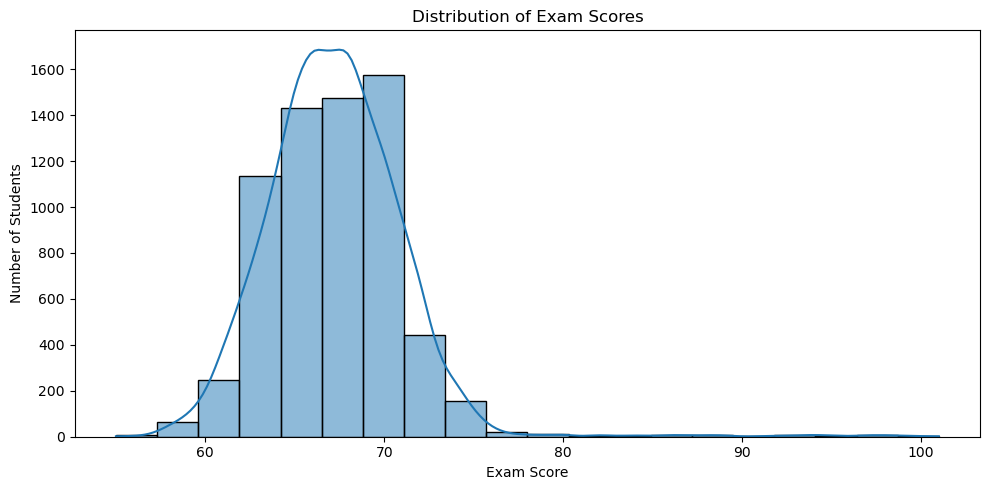

In [34]:
# Visualize the distribution of student examination scores

plt.figure(figsize=(10, 5))
sns.histplot(df["Exam_Score"], bins=20, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

In [36]:
# Examine correlations between numerical variables and the exam score

numerical_columns = df.select_dtypes(include=np.number).columns
correlation_with_exam = (
    df[numerical_columns]
    .corr()["Exam_Score"]
    .sort_values(ascending=False)
)
print("Correlation with Exam Score:")
print(correlation_with_exam)

Correlation with Exam Score:
Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


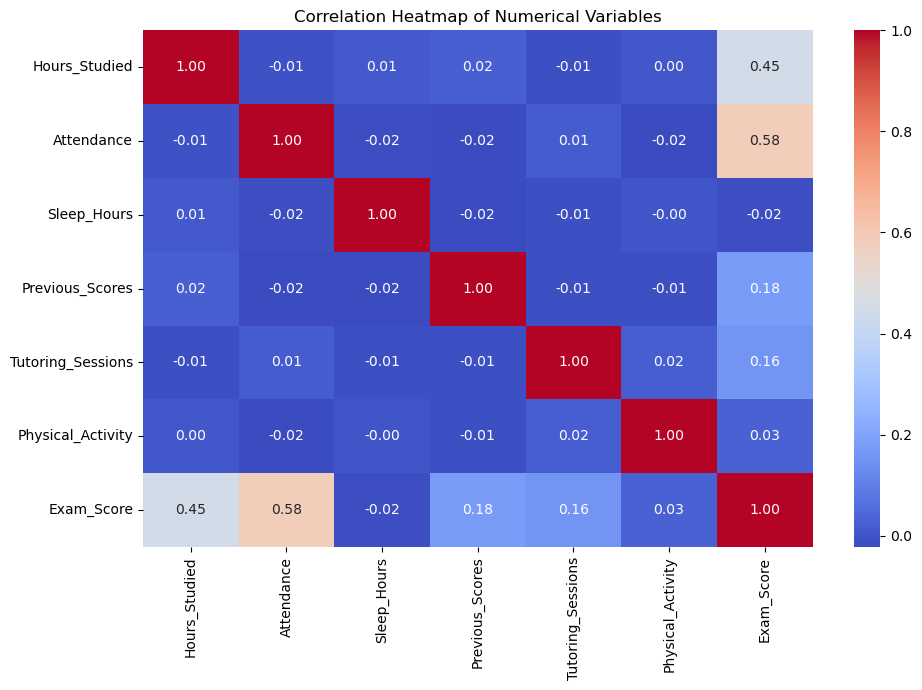

In [38]:
# Visualize correlations between numerical variables using a heatmap

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap of Numerical Variables")

plt.tight_layout()
plt.show()

In [40]:
# Create a copy of the original dataset so the raw data remains unchanged

df_clean = df.copy()
print("Original dataset shape:", df.shape)
print("Working dataset shape:", df_clean.shape)

Original dataset shape: (6607, 20)
Working dataset shape: (6607, 20)


In [42]:
# Handle missing values using mode for categorical columns and median for numerical columns

categorical_columns = df_clean.select_dtypes(include="object").columns
numerical_columns = df_clean.select_dtypes(include=np.number).columns
# Fill missing categorical values with the most frequent value
for column in categorical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])
# Fill missing numerical values with the median
for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())
print("Missing values after cleaning:")
print(df_clean.isnull().sum().sum())

Missing values after cleaning:
0


In [44]:
# Check for duplicate records after handling missing values

duplicate_count = df_clean.duplicated().sum()
print("Duplicate Records:", duplicate_count)

Duplicate Records: 0


In [46]:
# Verify the cleaned dataset structure before machine learning

print("Cleaned Dataset Shape:", df_clean.shape)
print("\nRemaining Missing Values:")
print(df_clean.isnull().sum().sum())
print("\nData Types:")
print(df_clean.dtypes)

Cleaned Dataset Shape: (6607, 20)

Remaining Missing Values:
0

Data Types:
Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object


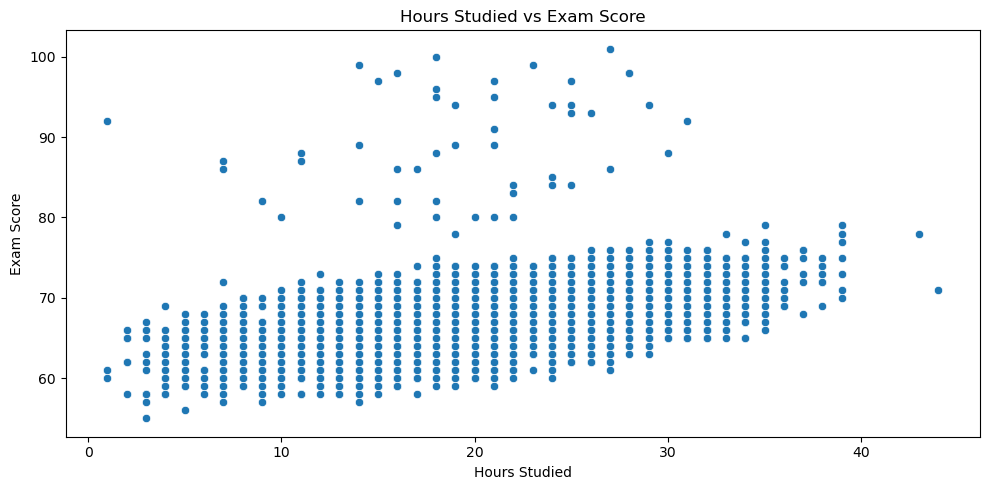

In [48]:
# Analyze the relationship between study hours and exam score

plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df_clean,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.tight_layout()
plt.show()

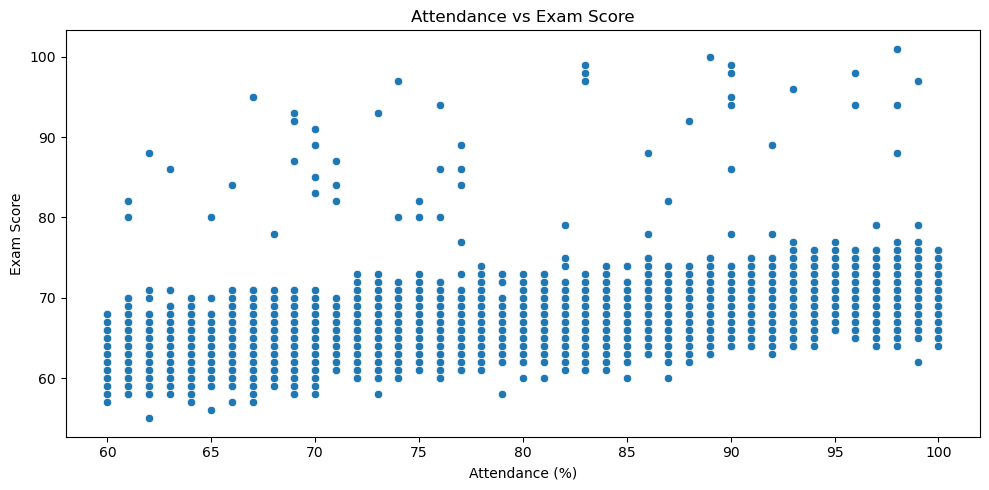

In [50]:
# Analyze the relationship between attendance and exam score

plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df_clean,
    x="Attendance",
    y="Exam_Score"
)
plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Exam Score")
plt.tight_layout()
plt.show()

Average Exam Score by Parental Involvement:
Parental_Involvement
High      68.092767
Medium    67.098156
Low       66.358265
Name: Exam_Score, dtype: float64


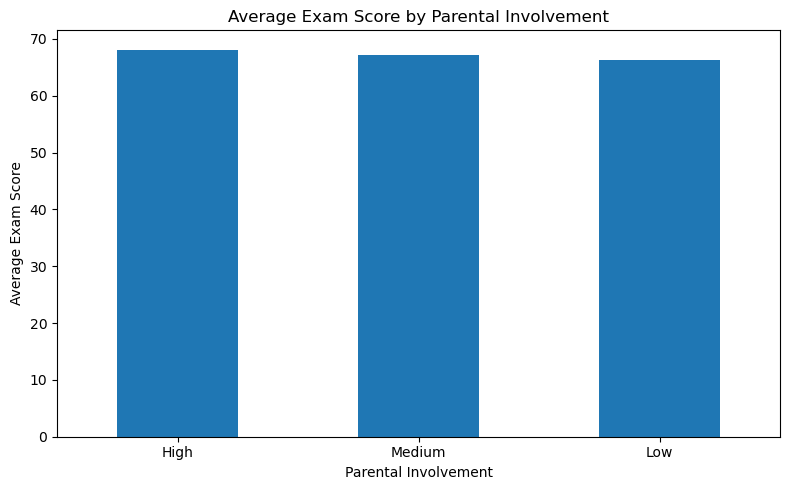

In [52]:
# Compare average exam scores based on parental involvement

parental_scores = (
    df_clean.groupby("Parental_Involvement")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Exam Score by Parental Involvement:")
print(parental_scores)
plt.figure(figsize=(8, 5))
parental_scores.plot(kind="bar")
plt.title("Average Exam Score by Parental Involvement")
plt.xlabel("Parental Involvement")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Exam Score by Access to Resources:
Access_to_Resources
High      68.092152
Medium    67.134378
Low       66.203351
Name: Exam_Score, dtype: float64


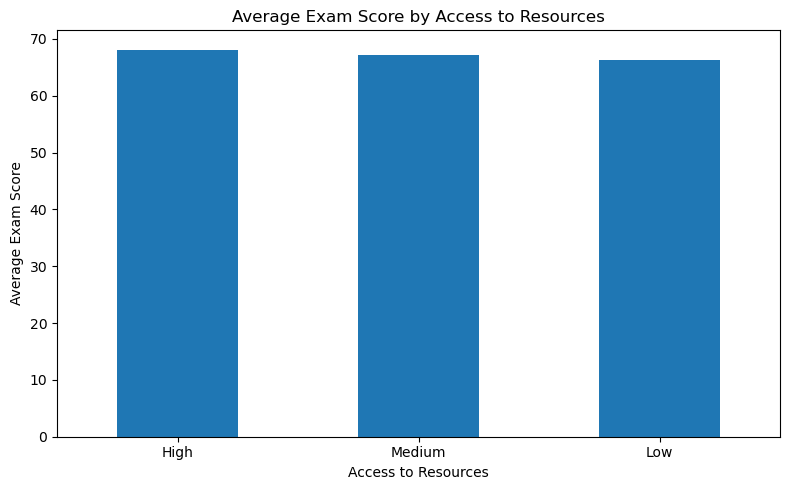

In [54]:
# Compare average exam scores based on access to educational resources

resource_scores = (
    df_clean.groupby("Access_to_Resources")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Exam Score by Access to Resources:")
print(resource_scores)
plt.figure(figsize=(8, 5))
resource_scores.plot(kind="bar")
plt.title("Average Exam Score by Access to Resources")
plt.xlabel("Access to Resources")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Exam Score by Motivation Level:
Motivation_Level
High      67.704321
Medium    67.330648
Low       66.752194
Name: Exam_Score, dtype: float64


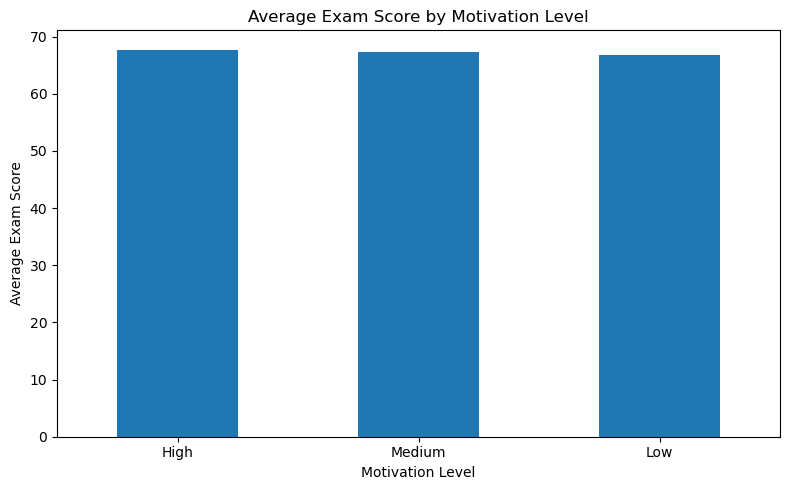

In [56]:
# Compare average exam scores based on student motivation level

motivation_scores = (
    df_clean.groupby("Motivation_Level")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Exam Score by Motivation Level:")
print(motivation_scores)
plt.figure(figsize=(8, 5))
motivation_scores.plot(kind="bar")
plt.title("Average Exam Score by Motivation Level")
plt.xlabel("Motivation Level")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Exam Score by Teacher Quality:
Teacher_Quality
High      67.676939
Medium    67.100175
Low       66.753425
Name: Exam_Score, dtype: float64


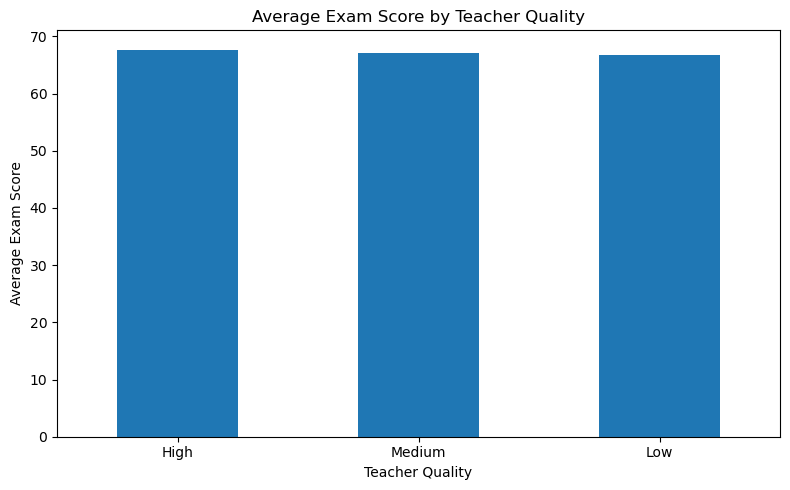

In [58]:
# Compare average exam scores based on teacher quality

teacher_scores = (
    df_clean.groupby("Teacher_Quality")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Exam Score by Teacher Quality:")
print(teacher_scores)
plt.figure(figsize=(8, 5))
teacher_scores.plot(kind="bar")
plt.title("Average Exam Score by Teacher Quality")
plt.xlabel("Teacher Quality")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Exam Score by School Type:
School_Type
Private    67.287705
Public     67.212919
Name: Exam_Score, dtype: float64


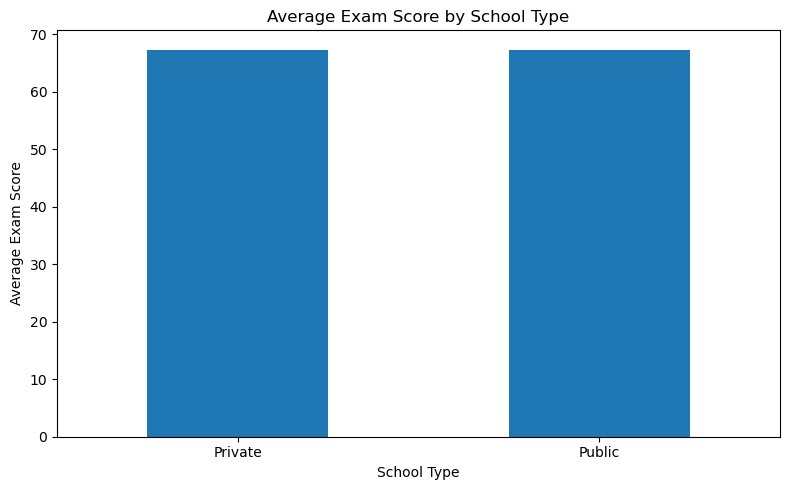

In [60]:
# Compare average exam scores between different school types

school_scores = (
    df_clean.groupby("School_Type")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Exam Score by School Type:")
print(school_scores)
plt.figure(figsize=(8, 5))
school_scores.plot(kind="bar")
plt.title("Average Exam Score by School Type")
plt.xlabel("School Type")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Average Exam Score by Internet Access:
Internet_Access
Yes    67.292895
No     66.535070
Name: Exam_Score, dtype: float64


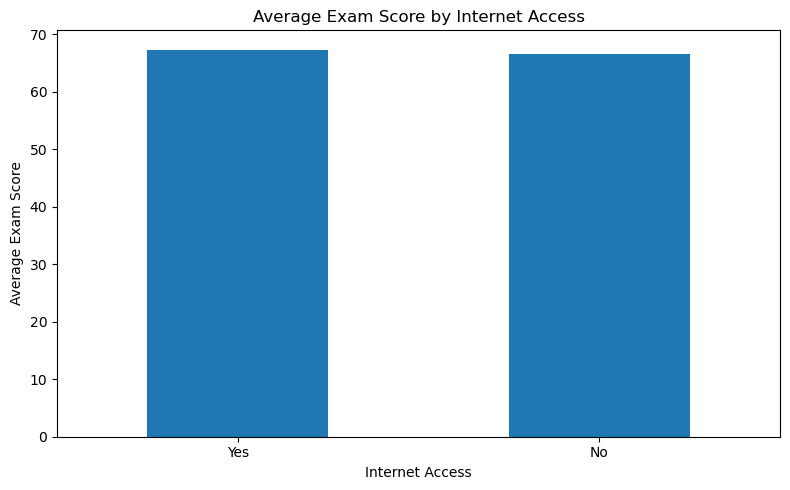

In [62]:
# Compare average exam scores based on internet access

internet_scores = (
    df_clean.groupby("Internet_Access")["Exam_Score"]
    .mean()
    .sort_values(ascending=False)
)
print("Average Exam Score by Internet Access:")
print(internet_scores)
plt.figure(figsize=(8, 5))
internet_scores.plot(kind="bar")
plt.title("Average Exam Score by Internet Access")
plt.xlabel("Internet Access")
plt.ylabel("Average Exam Score")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [64]:
# Identify the numerical variables most strongly related to exam score

predictor_correlation = (
    df_clean.select_dtypes(include=np.number)
    .corr()["Exam_Score"]
    .drop("Exam_Score")
    .abs()
    .sort_values(ascending=False)
)
print("Numerical Predictors Ranked by Correlation:")
print(predictor_correlation)

Numerical Predictors Ranked by Correlation:
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours          0.017022
Name: Exam_Score, dtype: float64


In [66]:
# Separate input features (X) from the target variable (y)

X = df_clean.drop("Exam_Score", axis=1)
y = df_clean["Exam_Score"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6607, 19)
Target shape: (6607,)


In [68]:
# Identify categorical and numerical features for preprocessing

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
print("Categorical Features:")
print(categorical_features)
print("\nNumerical Features:")
print(numerical_features)


Categorical Features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']

Numerical Features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']


In [70]:
# Create preprocessing pipelines for numerical and categorical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
# Numerical features require median-based imputation
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])
# Categorical features require mode-based imputation and one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])
# Combine both preprocessing pipelines
preprocessor = ColumnTransformer([
    ("numerical", numerical_pipeline, numerical_features),
    ("categorical", categorical_pipeline, categorical_features)
])
print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [72]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (5285, 19)
Testing features shape: (1322, 19)
Training target shape: (5285,)
Testing target shape: (1322,)


In [74]:
# Fit the preprocessing pipeline on training data and transform both datasets

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)
print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (5285, 40)
Processed testing data shape: (1322, 40)


In [76]:
# Verify that preprocessing produced clean numerical data

print("Processed training data type:", type(X_train_processed))
print("Processed testing data type:", type(X_test_processed))

print("Training data contains NaN:", np.isnan(X_train_processed).any())
print("Testing data contains NaN:", np.isnan(X_test_processed).any())

Processed training data type: <class 'numpy.ndarray'>
Processed testing data type: <class 'numpy.ndarray'>
Training data contains NaN: False
Testing data contains NaN: False


In [78]:
# Import regression models for student exam score prediction

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

print("Machine learning models imported successfully.")

Machine learning models imported successfully.


In [80]:
# Create multiple regression models for comparison

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,
        random_state=42
    )
}

print("Models created:")
for model_name in models:
    print("-", model_name)

Models created:
- Linear Regression
- Decision Tree
- Random Forest
- Gradient Boosting


In [82]:
# Train each machine learning model using the processed training data

trained_models = {}

for model_name, model in models.items():
    model.fit(X_train_processed, y_train)
    trained_models[model_name] = model
    print(f"{model_name} trained successfully.")

Linear Regression trained successfully.
Decision Tree trained successfully.
Random Forest trained successfully.
Gradient Boosting trained successfully.


In [84]:
# Generate exam score predictions using the trained models

predictions = {}

for model_name, model in trained_models.items():
    predictions[model_name] = model.predict(X_test_processed)
    print(f"{model_name} predictions generated.")

Linear Regression predictions generated.
Decision Tree predictions generated.
Random Forest predictions generated.
Gradient Boosting predictions generated.


In [86]:
# Evaluate model performance using MAE, MSE, RMSE, and R2 score

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model_results = []

for model_name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    model_results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2 Score": r2
    })

results_df = pd.DataFrame(model_results)

print("Model Evaluation Results:")
results_df

Model Evaluation Results:


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.452390,3.256017,1.804444,0.769650
1,Decision Tree,1.742057,12.506051,3.536390,0.115247
2,Random Forest,1.084145,4.690431,2.165740,0.668171
3,Gradient Boosting,0.791782,3.769902,1.941624,0.733294


In [88]:
# Rank the models according to their R2 score

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("Models ranked by R2 Score:")
results_df

Models ranked by R2 Score:


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.452390,3.256017,1.804444,0.769650
1,Gradient Boosting,0.791782,3.769902,1.941624,0.733294
2,Random Forest,1.084145,4.690431,2.165740,0.668171
3,Decision Tree,1.742057,12.506051,3.536390,0.115247


In [90]:
# Identify the best-performing machine learning model

best_model_name = results_df.loc[0, "Model"]
best_model = trained_models[best_model_name]
print("Best Model:", best_model_name)
print("Best R2 Score:", round(results_df.loc[0, "R2 Score"], 4))
print("Best RMSE:", round(results_df.loc[0, "RMSE"], 4))
print("Best MAE:", round(results_df.loc[0, "MAE"], 4))

Best Model: Linear Regression
Best R2 Score: 0.7696
Best RMSE: 1.8044
Best MAE: 0.4524


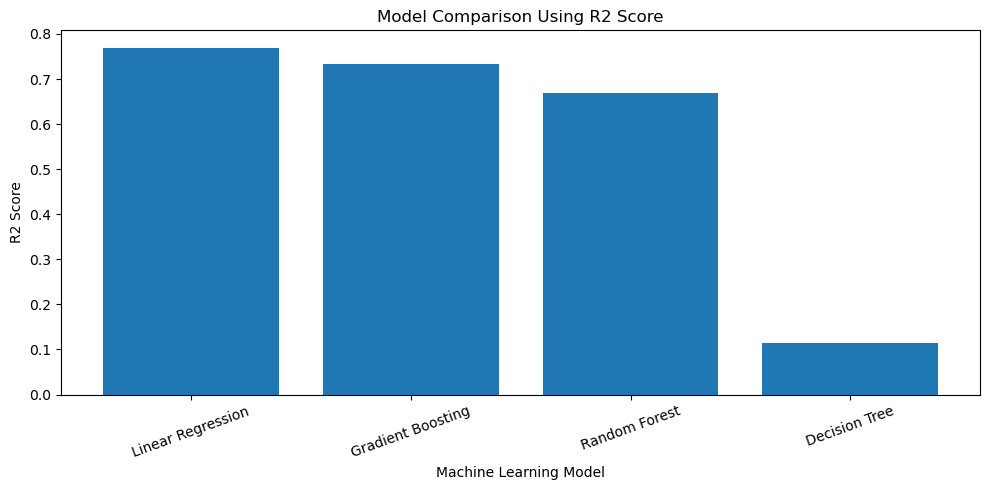

In [92]:
# Visualize and compare the R2 scores of all trained models

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["Model"],
    results_df["R2 Score"]
)

plt.title("Model Comparison Using R2 Score")
plt.xlabel("Machine Learning Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

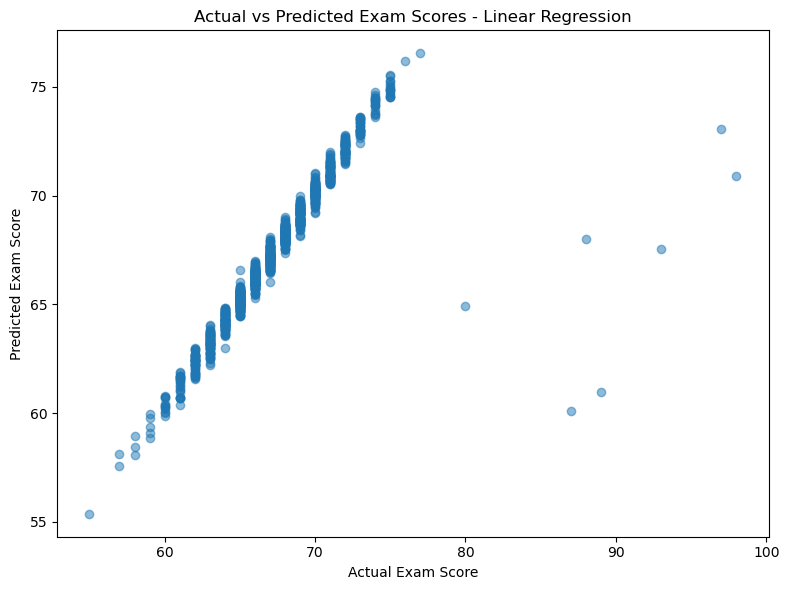

In [94]:
# Compare actual exam scores with predictions from the best model

best_predictions = predictions[best_model_name]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title(f"Actual vs Predicted Exam Scores - {best_model_name}")

plt.tight_layout()
plt.show()


In [96]:

# Analyze the prediction errors of the best-performing model

prediction_errors = y_test - best_predictions

print("Prediction Error Statistics:")
print(pd.Series(prediction_errors).describe())

Prediction Error Statistics:
count    1322.000000
mean       -0.049161
std         1.804457
min        -1.570876
25%        -0.447526
50%        -0.182920
75%         0.096647
max        28.010264
Name: Exam_Score, dtype: float64


In [98]:
# Analyze the prediction errors of the best-performing model

prediction_errors = y_test - best_predictions

print("Prediction Error Statistics:")
print(pd.Series(prediction_errors).describe())

print("\nMean Prediction Error:", round(prediction_errors.mean(), 4))
print("Mean Absolute Error:", round(np.abs(prediction_errors).mean(), 4))
print("Maximum Absolute Error:", round(np.abs(prediction_errors).max(), 4))

Prediction Error Statistics:
count    1322.000000
mean       -0.049161
std         1.804457
min        -1.570876
25%        -0.447526
50%        -0.182920
75%         0.096647
max        28.010264
Name: Exam_Score, dtype: float64

Mean Prediction Error: -0.0492
Mean Absolute Error: 0.4524
Maximum Absolute Error: 28.0103


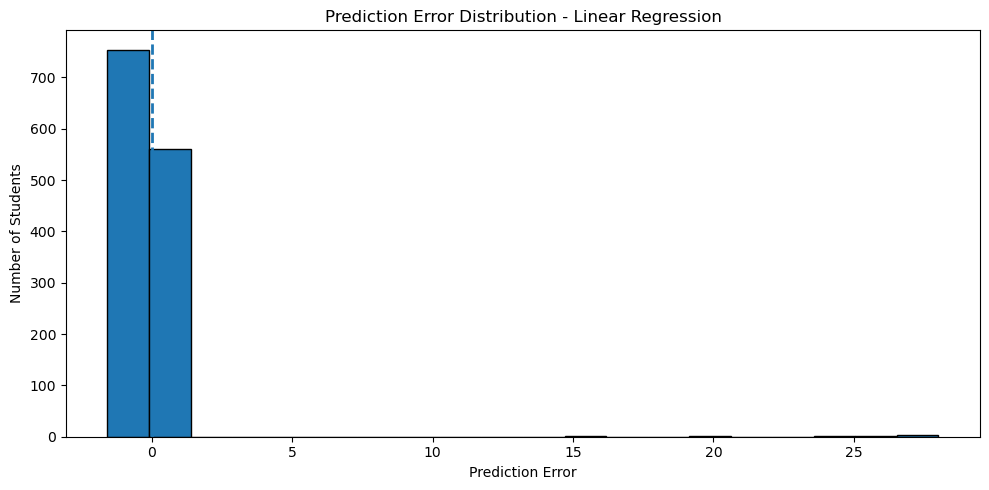

In [100]:
# Visualize prediction errors of the best-performing model

plt.figure(figsize=(10, 5))

plt.hist(prediction_errors, bins=20, edgecolor="black")

plt.axvline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Prediction Error Distribution - Linear Regression")
plt.xlabel("Prediction Error")
plt.ylabel("Number of Students")

plt.tight_layout()
plt.show()


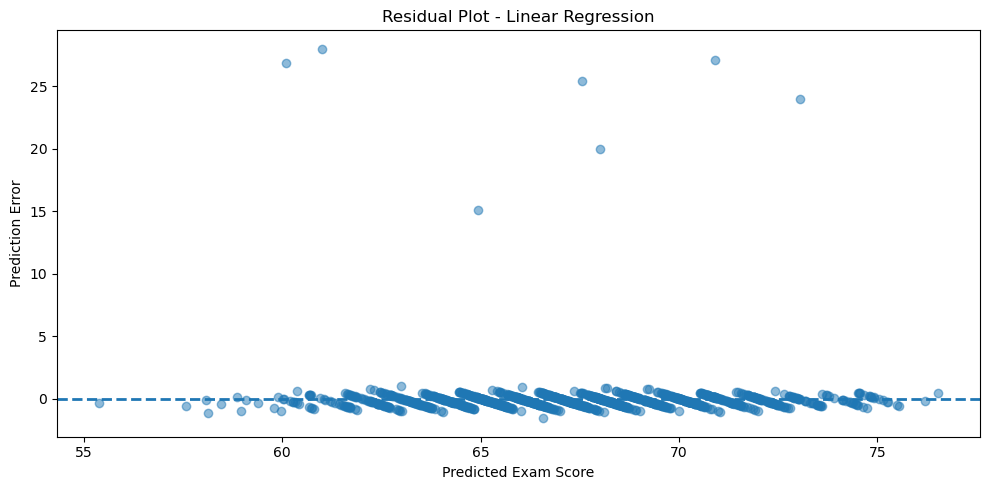

In [102]:

# Visualize residuals against predicted exam scores

plt.figure(figsize=(10, 5))

plt.scatter(
    best_predictions,
    prediction_errors,
    alpha=0.5
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=2
)

plt.title("Residual Plot - Linear Regression")
plt.xlabel("Predicted Exam Score")
plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()


In [104]:

# Create a final summary of the selected model

best_results = results_df.iloc[0]

print("FINAL MODEL SUMMARY")
print("=" * 40)

print("Selected Model:", best_model_name)
print("R2 Score:", round(best_results["R2 Score"], 4))
print("RMSE:", round(best_results["RMSE"], 4))
print("MAE:", round(best_results["MAE"], 4))

print("\nModel Interpretation:")
print(
    f"The {best_model_name} model achieved the highest R2 score "
    f"of {best_results['R2 Score']:.4f} among the models tested."
)


FINAL MODEL SUMMARY
Selected Model: Linear Regression
R2 Score: 0.7696
RMSE: 1.8044
MAE: 0.4524

Model Interpretation:
The Linear Regression model achieved the highest R2 score of 0.7696 among the models tested.


In [106]:

# Create a function to predict exam score for a new student

def predict_exam_score(student_data):
    """
    Predict the exam score for a new student.

    student_data should be a dictionary containing
    the same feature names used during model training.
    """    
    student_df = pd.DataFrame([student_data])
    
    # Apply the same preprocessing used during training
    student_processed = preprocessor.transform(student_df)   
    # Predict using the best-performing model
    predicted_score = best_model.predict(student_processed)[0]   
    return predicted_score
print("Prediction function created successfully.")# Create a function to predict exam score for a new student

def predict_exam_score(student_data):
    """
    Predict the exam score for a new student.

    student_data should be a dictionary containing
    the same feature names used during model training.
    """    
    student_df = pd.DataFrame([student_data])
    
    # Apply the same preprocessing used during training
    student_processed = preprocessor.transform(student_df)  
    # Predict using the best-performing model
    predicted_score = best_model.predict(student_processed)[0]
    return predicted_score
print("Prediction function created successfully.")


Prediction function created successfully.
Prediction function created successfully.


In [108]:

# Example student for prediction

sample_student = {
    "Hours_Studied": 25,
    "Attendance": 90,
    "Parental_Involvement": "High",
    "Access_to_Resources": "High",
    "Extracurricular_Activities": "Yes",
    "Sleep_Hours": 7,
    "Previous_Scores": 80,
    "Motivation_Level": "High",
    "Internet_Access": "Yes",
    "Tutoring_Sessions": 3,
    "Family_Income": "Medium",
    "Teacher_Quality": "High",
    "School_Type": "Private",
    "Peer_Influence": "Positive",
    "Physical_Activity": 4,
    "Learning_Disabilities": "No",
    "Parental_Education_Level": "College",
    "Distance_from_Home": "Near",
    "Gender": "Female"
}

predicted_score = predict_exam_score(sample_student)

print("Student Exam Score Prediction")
print("=" * 40)
print("Predicted Exam Score:", round(predicted_score, 2))


Student Exam Score Prediction
Predicted Exam Score: 76.08


In [110]:

# Interpret the predicted exam score

if predicted_score >= 90:
    performance = "Excellent"
elif predicted_score >= 80:
    performance = "Very Good"
elif predicted_score >= 70:
    performance = "Good"
elif predicted_score >= 60:
    performance = "Average"
else:
    performance = "Needs Improvement"

print("Predicted Exam Score:", round(predicted_score, 2))
print("Performance Level:", performance)


Predicted Exam Score: 76.08
Performance Level: Good


In [112]:

# Save the final model and preprocessing pipeline

import joblib

joblib.dump(best_model, "student_exam_score_model.pkl")
joblib.dump(preprocessor, "student_exam_score_preprocessor.pkl")

print("Model saved successfully.")
print("Preprocessor saved successfully.")


Model saved successfully.
Preprocessor saved successfully.


In [114]:

# Verify that the saved model and preprocessor can be loaded

loaded_model = joblib.load("student_exam_score_model.pkl")
loaded_preprocessor = joblib.load("student_exam_score_preprocessor.pkl")
print("Saved model loaded successfully.")
print("Saved preprocessor loaded successfully.")


Saved model loaded successfully.
Saved preprocessor loaded successfully.


In [116]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [118]:
# Validate the final Linear Regression model on the test dataset

final_predictions = loaded_model.predict(
    loaded_preprocessor.transform(X_test)
)

final_mae = mean_absolute_error(y_test, final_predictions)
final_mse = mean_squared_error(y_test, final_predictions)
final_rmse = np.sqrt(final_mse)
final_r2 = r2_score(y_test, final_predictions)

print("FINAL MODEL VALIDATION")
print("=" * 40)
print("Model:", best_model_name)
print("MAE:", round(final_mae, 4))
print("MSE:", round(final_mse, 4))
print("RMSE:", round(final_rmse, 4))
print("R2 Score:", round(final_r2, 4))

FINAL MODEL VALIDATION
Model: Linear Regression
MAE: 0.4524
MSE: 3.256
RMSE: 1.8044
R2 Score: 0.7696


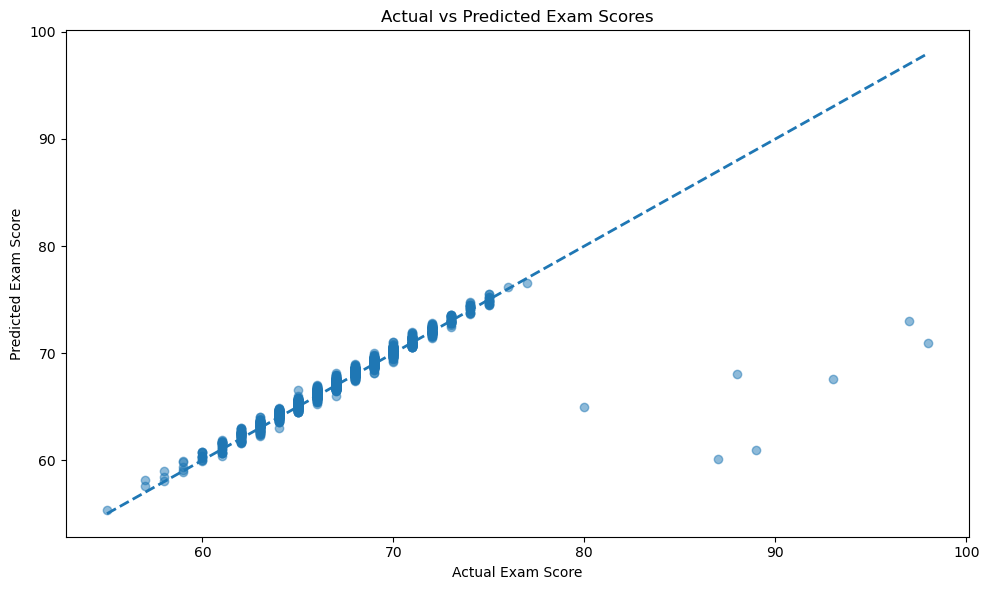

In [120]:
# Compare actual and predicted exam scores

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    final_predictions,
    alpha=0.5
)

min_score = min(y_test.min(), final_predictions.min())
max_score = max(y_test.max(), final_predictions.max())

plt.plot(
    [min_score, max_score],
    [min_score, max_score],
    linestyle="--",
    linewidth=2
)

plt.title("Actual vs Predicted Exam Scores")
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.tight_layout()
plt.show()

In [122]:
# Analyze Linear Regression coefficients

feature_names = loaded_preprocessor.get_feature_names_out()

coefficients = loaded_model.coef_

coefficient_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients,
    "Absolute_Coefficient": np.abs(coefficients)
})

coefficient_df = coefficient_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Top Features Influencing Exam Score:")
print(coefficient_df.head(15).to_string(index=False))

Top Features Influencing Exam Score:
                                           Feature   Coefficient  Absolute_Coefficient
                categorical__Motivation_Level_High  1.698522e+10          1.698522e+10
              categorical__Motivation_Level_Medium  1.698522e+10          1.698522e+10
                 categorical__Motivation_Level_Low  1.698522e+10          1.698522e+10
              categorical__Distance_from_Home_Near  1.276905e+10          1.276905e+10
          categorical__Distance_from_Home_Moderate  1.276905e+10          1.276905e+10
               categorical__Distance_from_Home_Far  1.276905e+10          1.276905e+10
             categorical__Parental_Involvement_Low -1.034626e+10          1.034626e+10
          categorical__Parental_Involvement_Medium -1.034626e+10          1.034626e+10
            categorical__Parental_Involvement_High -1.034626e+10          1.034626e+10
 categorical__Parental_Education_Level_High School -7.045848e+09          7.045848e+09
     c

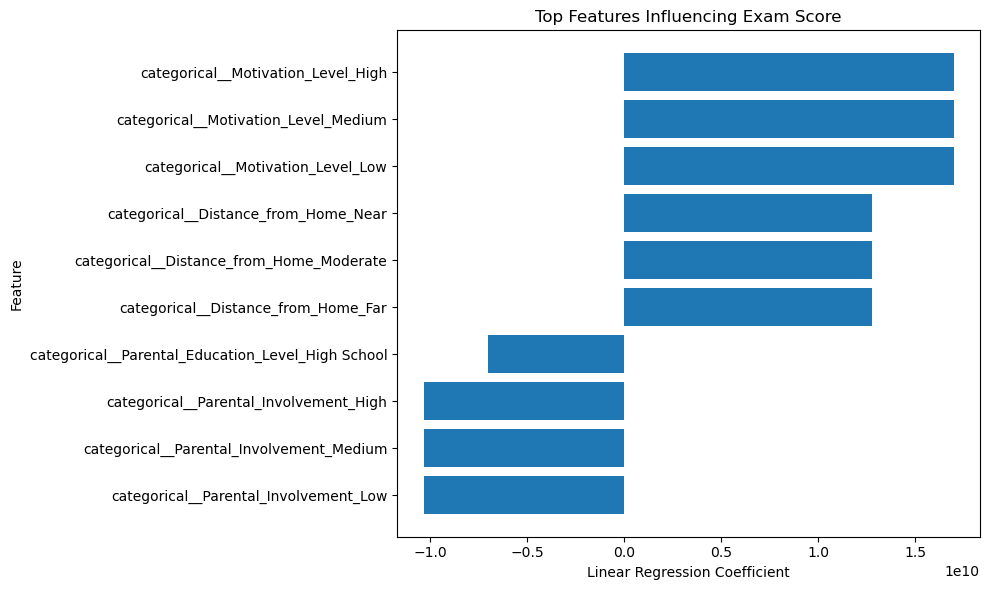

In [124]:
# Visualize the most influential features

top_features = coefficient_df.head(10).sort_values(
    by="Coefficient"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.title("Top Features Influencing Exam Score")
plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [126]:
# Create a clean model comparison table

final_comparison = results_df.copy()

final_comparison = final_comparison.sort_values(
    by="R2 Score",
    ascending=False
).reset_index(drop=True)

print("FINAL MODEL COMPARISON")
print("=" * 70)

display(
    final_comparison.round(4)
)

FINAL MODEL COMPARISON


,Model,MAE,MSE,RMSE,R2 Score
0,Linear Regression,0.4524,3.2560,1.8044,0.7696
1,Gradient Boosting,0.7918,3.7699,1.9416,0.7333
2,Random Forest,1.0841,4.6904,2.1657,0.6682
3,Decision Tree,1.7421,12.5061,3.5364,0.1152


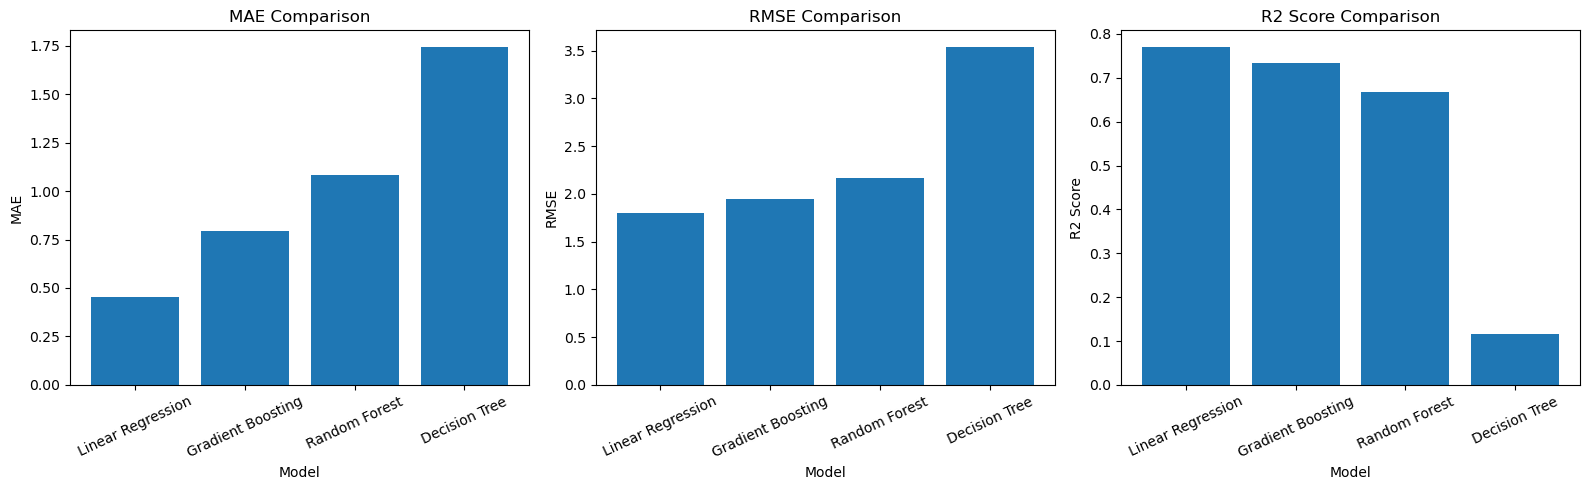

In [128]:
# Visualize model performance using MAE, RMSE, and R2 Score

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# MAE
axes[0].bar(
    final_comparison["Model"],
    final_comparison["MAE"]
)
axes[0].set_title("MAE Comparison")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("MAE")
axes[0].tick_params(axis="x", rotation=25)

# RMSE
axes[1].bar(
    final_comparison["Model"],
    final_comparison["RMSE"]
)
axes[1].set_title("RMSE Comparison")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("RMSE")
axes[1].tick_params(axis="x", rotation=25)

# R2
axes[2].bar(
    final_comparison["Model"],
    final_comparison["R2 Score"]
)
axes[2].set_title("R2 Score Comparison")
axes[2].set_xlabel("Model")
axes[2].set_ylabel("R2 Score")
axes[2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

In [130]:
# Final project conclusions

print("PROJECT CONCLUSION")
print("=" * 60)

print(f"""
1. The dataset contains {df.shape[0]} student records and {df.shape[1]} features.

2. Missing values were identified and handled using appropriate
   imputation techniques.

3. Categorical variables were converted into numerical form using
   One-Hot Encoding.

4. The dataset was divided into training and testing sets using
   an 80:20 split.

5. Four regression models were trained and evaluated:
   - Linear Regression
   - Decision Tree
   - Random Forest
   - Gradient Boosting

6. Linear Regression achieved the best overall performance.

7. Final Linear Regression performance:
   R2 Score = {final_r2:.4f}
   RMSE = {final_rmse:.4f}
   MAE = {final_mae:.4f}

8. The trained model can predict the expected exam score of a
   new student based on academic, behavioral, and demographic
   characteristics.

9. The final trained model and preprocessing pipeline were saved
   for future use.
""")

PROJECT CONCLUSION

1. The dataset contains 6607 student records and 20 features.

2. Missing values were identified and handled using appropriate
   imputation techniques.

3. Categorical variables were converted into numerical form using
   One-Hot Encoding.

4. The dataset was divided into training and testing sets using
   an 80:20 split.

5. Four regression models were trained and evaluated:
   - Linear Regression
   - Decision Tree
   - Random Forest
   - Gradient Boosting

6. Linear Regression achieved the best overall performance.

7. Final Linear Regression performance:
   R2 Score = 0.7696
   RMSE = 1.8044
   MAE = 0.4524

8. The trained model can predict the expected exam score of a
   new student based on academic, behavioral, and demographic
   characteristics.

9. The final trained model and preprocessing pipeline were saved
   for future use.



In [132]:
# Final prediction demonstration

final_student = sample_student.copy()

final_prediction = predict_exam_score(final_student)

print("FINAL STUDENT SCORE PREDICTION")
print("=" * 45)

print("Predicted Exam Score:", round(final_prediction, 2))

if final_prediction >= 90:
    performance_level = "Excellent"
elif final_prediction >= 80:
    performance_level = "Very Good"
elif final_prediction >= 70:
    performance_level = "Good"
elif final_prediction >= 60:
    performance_level = "Average"
else:
    performance_level = "Needs Improvement"

print("Performance Level:", performance_level)

FINAL STUDENT SCORE PREDICTION
Predicted Exam Score: 76.08
Performance Level: Good
